**Step 1: Risk-Aware Multi-Armed Bandit for Portfolio**

In [ ]:
# Member A
import yfinance as yf
import pandas as pd

# Final list of 30 tickers
tickers = [
    'JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF',
    'AXP', 'PRU', 'SCHW', 'FITB', 'HBAN',
    'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'VTR', 'EQIX', 'DUK',
    'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS'
]

start_date = '2008-09-02'
end_date = '2008-10-31'

# --- Final Working Code - Revision 2 ---

# Step 1: Download all data
print("Downloading data...")
raw_data = yf.download(tickers, start=start_date, end=end_date)
print("Download complete.")

# Step 2: THE FIX - Use 'Close' price instead of 'Adj Close'
# This is a common adaptation when 'Adj Close' data is unavailable.
print("Attempting to select 'Close' price column...")
data = raw_data['Close']
print("'Close' price selected successfully.")

# Step 3: Final Quality Check and Save
print("\n--- Final Data Head ---")
print(data.head())

# Save the final data to CSV
data.to_csv('stock_prices_2008_cleaned.csv')
print("\nSuccess! Step 3 is complete. Data is saved using 'Close' prices.")

/tmp/ipython-input-1301800445.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  30 of 30 completed


Download complete.
Attempting to select 'Close' price column...
'Close' price selected successfully.

--- Final Data Head ---
Ticker            APA        AXP        BAC           C       CMS        COF  \
Date                                                                           
2008-09-02  78.489357  31.142025  24.401865  140.539795  7.713428  34.013210   
2008-09-03  79.330811  31.356653  25.141777  144.216873  7.622746  34.573540   
2008-09-04  81.212944  29.701054  23.341572  134.582825  7.634084  32.809273   
2008-09-05  82.246300  30.199278  24.584936  140.245575  7.560409  33.854187   
2008-09-08  81.021011  31.057718  26.491930  149.438370  7.792776  36.898132   

Ticker           CSCO       DAL        DUK       EQIX  ...       PFE  \
Date                                                   ...             
2008-09-02  15.542994  7.948209  24.425381  60.890450  ...  8.992184   
2008-09-03  15.255037  7.896207  24.115486  60.288692  ...  9.006253   
2008-09-04  14.580959  7.

In [ ]:
# Member C
import pandas as pd
import numpy as np

# Load the data collected by Member A
data = pd.read_csv('stock_prices_2008_cleaned.csv', index_col=0, parse_dates=True)

# Verify we have all 30 tickers
print("Available tickers:", data.columns.tolist())
print("Date range:", data.index.min(), "to", data.index.max())

# 1. Combine into a single DataFrame (already done by Member A)
# The data is already in a suitable time series structure with dates as index

# 2. Compute daily returns (log returns as used in the paper)
print("\nCalculating daily log returns...")
returns = np.log(data / data.shift(1)).dropna()

# Alternative: If you want simple percentage returns instead:
# returns = data.pct_change().dropna()

# 3. Save the returns data
returns.to_csv('daily_returns_2008.csv')

# 4. Display summary statistics
print("\n--- Returns Summary Statistics ---")
print(returns.describe())

print("\nSuccess! Daily returns calculated and saved.")

Available tickers: ['APA', 'AXP', 'BAC', 'C', 'CMS', 'COF', 'CSCO', 'DAL', 'DUK', 'EQIX', 'F', 'FITB', 'GE', 'GS', 'HBAN', 'JPM', 'KEY', 'KR', 'MS', 'NFLX', 'PFE', 'PNC', 'PRU', 'REGN', 'SCHW', 'USB', 'VTR', 'WFC', 'WMT', 'XOM']
Date range: 2008-09-02 00:00:00 to 2008-10-30 00:00:00

Calculating daily log returns...

--- Returns Summary Statistics ---
             APA        AXP        BAC          C        CMS        COF  \
count  42.000000  42.000000  42.000000  42.000000  42.000000  42.000000   
mean   -0.007043  -0.010453  -0.008084  -0.008675  -0.006086  -0.003908   
std     0.076125   0.070530   0.102153   0.095375   0.044571   0.079150   
min    -0.201339  -0.193523  -0.304163  -0.203886  -0.086648  -0.214929   
25%    -0.049439  -0.050274  -0.067281  -0.065367  -0.040162  -0.052550   
50%    -0.011751  -0.011730  -0.005314  -0.021260  -0.008171  -0.012523   
75%     0.044377   0.027573   0.058915   0.036291   0.013285   0.031273   
max     0.193239   0.164892   0.203461   0.215

**Step 4: Heatmap of the Correlation Matrix**

Data loaded successfully. Here are the first 5 rows:
                  APA        AXP        BAC           C       CMS        COF  \
Date                                                                           
2008-09-02  78.489357  31.142025  24.401865  140.539795  7.713428  34.013210   
2008-09-03  79.330811  31.356653  25.141777  144.216873  7.622746  34.573540   
2008-09-04  81.212944  29.701054  23.341572  134.582825  7.634084  32.809273   
2008-09-05  82.246300  30.199278  24.584936  140.245575  7.560409  33.854187   
2008-09-08  81.021011  31.057718  26.491930  149.438370  7.792776  36.898132   

                 CSCO       DAL        DUK       EQIX  ...       PFE  \
Date                                                   ...             
2008-09-02  15.542994  7.948209  24.425381  60.890450  ...  8.992184   
2008-09-03  15.255037  7.896207  24.115486  60.288692  ...  9.006253   
2008-09-04  14.580959  7.766192  24.354942  58.295372  ...  8.757645   
2008-09-05  14.567879  7.6

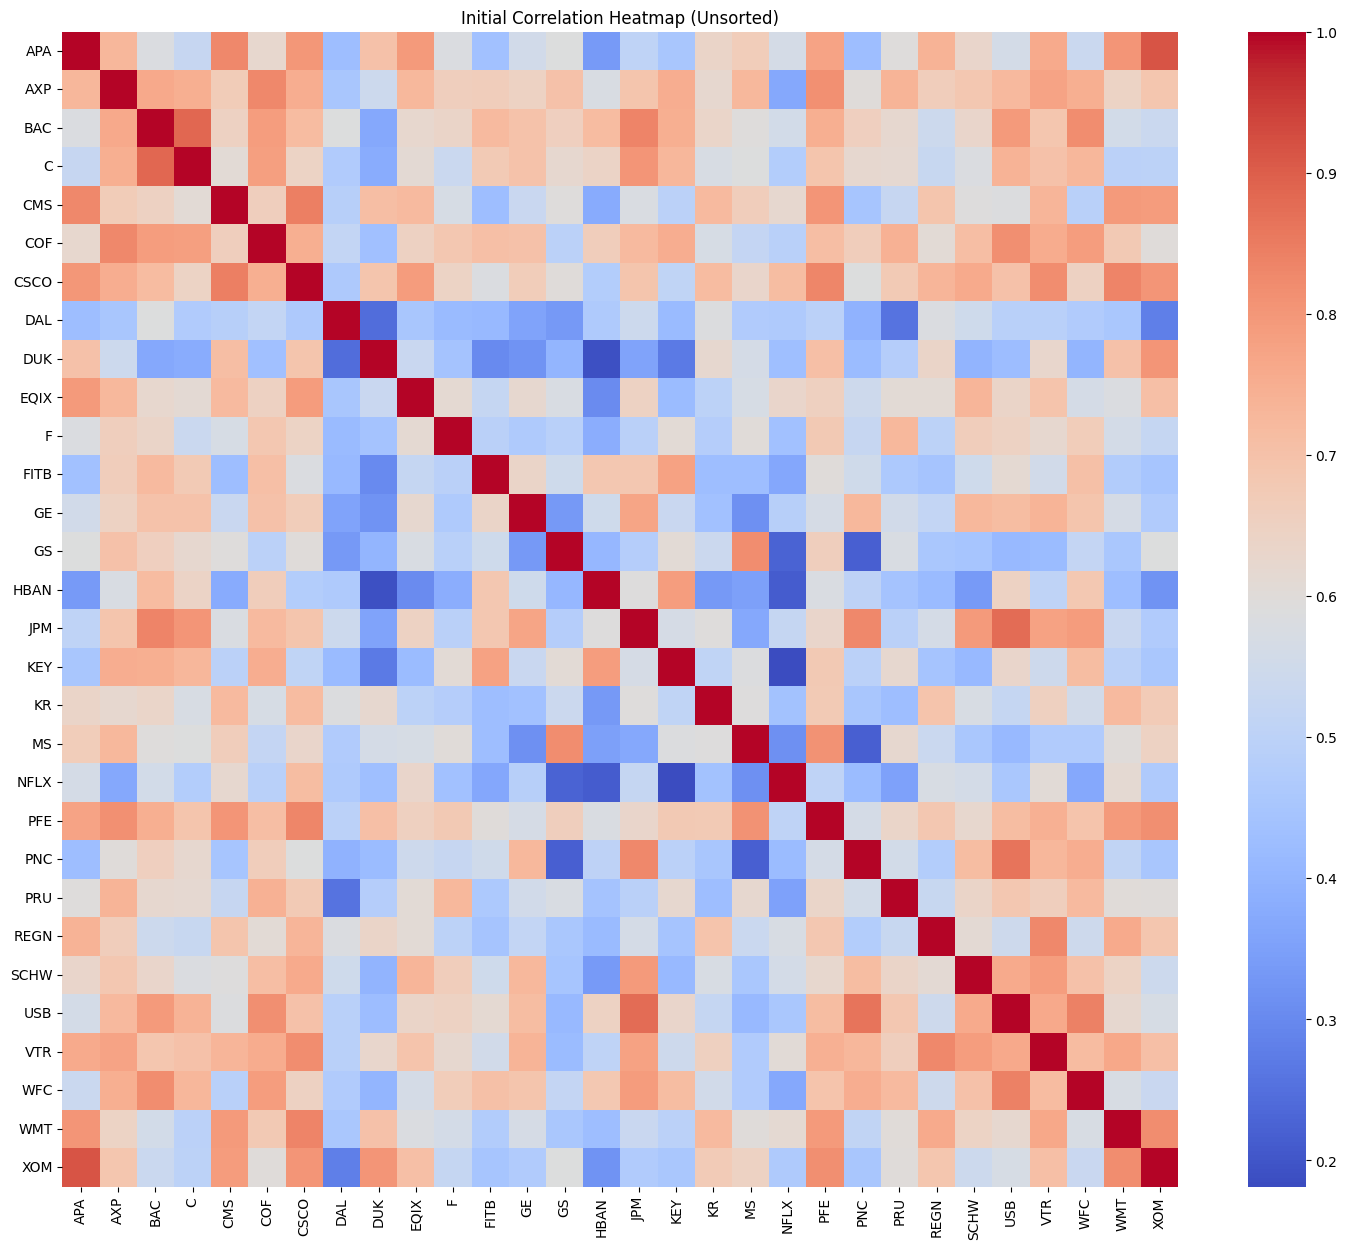

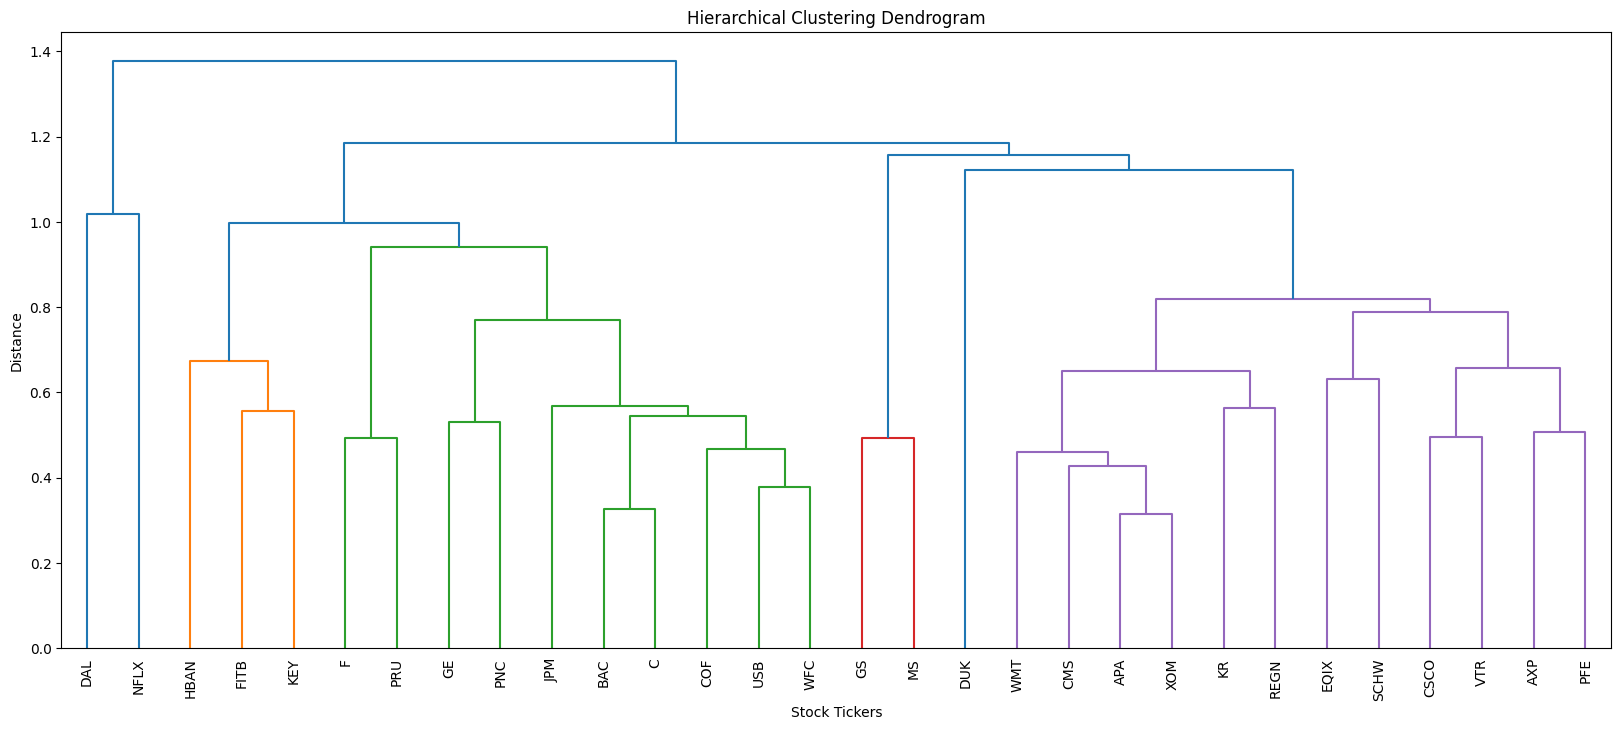

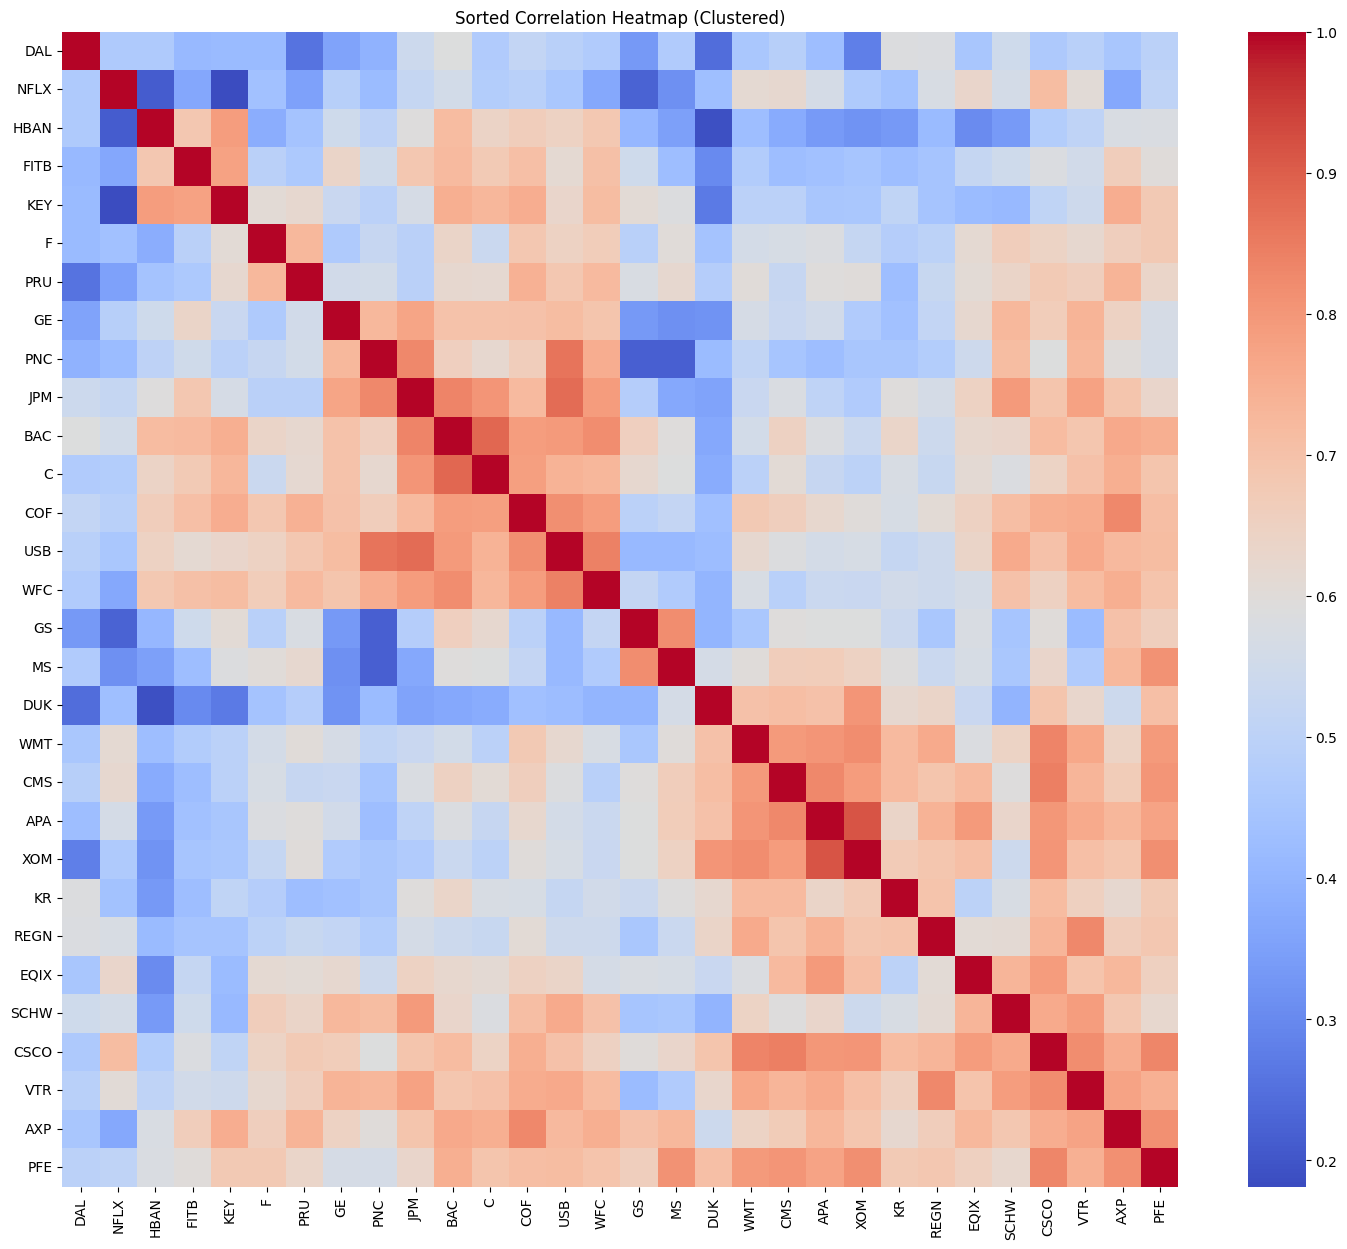

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

# --- Step 4.1: Load and Prepare Data ---

# Load the cleaned closing price data from the CSV file.
# 'index_col' sets the 'Date' column as the DataFrame's index.
# 'parse_dates' ensures the index is treated as a datetime object.
file_path = 'stock_prices_2008_cleaned.csv'
prices_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print("Data loaded successfully. Here are the first 5 rows:")
print(prices_df.head())


# --- Step 4.2: Calculate Daily Log Returns ---

# Calculate Log Returns: log(P_t / P_{t-1})
# .shift(1) moves the data down by one row to align P_t with P_{t-1}.
log_returns_df = np.log(prices_df / prices_df.shift(1))

# The first row will be NaN (since there's no prior day), so we must drop it.
log_returns_df = log_returns_df.dropna()

print("\nLog returns calculated. Here are the first 5 rows of returns:")
print(log_returns_df.head())


# --- Step 4.3: Compute the Correlation Matrix ---

# Compute the 30x30 correlation matrix from the log returns.
correlation_matrix = log_returns_df.corr()

print("\nCorrelation matrix calculated. Shape:", correlation_matrix.shape)
print(correlation_matrix.head())


# --- Step 4.4: Visualize the Initial Heatmap ---

# Create the initial heatmap (unsorted) to see the raw correlations.
plt.figure(figsize=(18, 15)) # Set the figure size for better readability.
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Initial Correlation Heatmap (Unsorted)')
plt.show()


# --- Step 4.5: Sort the Matrix with Hierarchical Clustering ---

# 1. Create the linkage matrix.
#    We must first convert the correlation matrix (a measure of similarity) into a distance matrix.
corr_condensed = hierarchy.distance.pdist(correlation_matrix)
z = hierarchy.linkage(corr_condensed, method='average')

# 2. Create a dendrogram to visualize the clusters.
plt.figure(figsize=(20, 8))
dendrogram = hierarchy.dendrogram(z, labels=correlation_matrix.columns, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Stock Tickers')
plt.ylabel('Distance')
plt.show()

# 3. Get the order of tickers from the dendrogram's leaves.
sorted_tickers = dendrogram['ivl']

# 4. Reorder the correlation matrix based on the clustering result.
sorted_correlation_matrix = correlation_matrix.loc[sorted_tickers, sorted_tickers]

# 5. Create the final, sorted heatmap.
plt.figure(figsize=(18, 15))
sns.heatmap(sorted_correlation_matrix, cmap='coolwarm')
plt.title('Sorted Correlation Heatmap (Clustered)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

# --- 1. Load Price Data ---
file_path = 'stock_prices_2008_cleaned.csv'
prices_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

# --- 2. Calculate Log Returns ---
log_returns_df = np.log(prices_df / prices_df.shift(1))
log_returns_df = log_returns_df.dropna()
print("Log returns calculated.")

# --- 3. SAVE THE LOG RETURNS TO A FILE (THIS IS THE FIX) ---
log_returns_df.to_csv('log_returns_df.csv')
print("Successfully saved log returns to 'log_returns_df.csv'")

# --- 4. Calculate Correlation and Create Visualizations ---
# (The rest of your Step 4 code to create heatmaps, etc.)
correlation_matrix = log_returns_df.corr()

# Create the sorted heatmap... (your existing code for heatmaps)
# ...

plt.show() # To display any plots you generated

Log returns calculated.
Successfully saved log returns to 'log_returns_df.csv'


**Step 6: UBC Algorithm: Team Member B's Implementation**

In [ ]:
import numpy as np
import pandas as pd

def ucb_algorithm(returns_data, c=2):
    """
    Implements the Upper Confidence Bound (UCB) algorithm for portfolio selection

    Parameters:
    returns_data (pd.DataFrame): DataFrame with stocks as columns and daily returns as rows
    c (float): Exploration parameter

    Returns:
    tuple: (selected_arms_history, cumulative_returns)
    """
    K = returns_data.shape[1]  # Number of stocks
    N = returns_data.shape[0]  # Number of days

    counts = np.zeros(K)       # N_k(t)
    values = np.zeros(K)       # Q_k(t)
    selected_arms_history = []
    cumulative_returns = []
    total_return = 1.0

    for t in range(N):
        selected_arm = -1
        max_upper_bound = -np.inf

        for k in range(K):
            if counts[k] > 0:
                average_reward = values[k] / counts[k]
                exploration_bonus = c * np.sqrt(np.log(t+1) / counts[k])
                upper_bound = average_reward + exploration_bonus
            else:
                upper_bound = np.inf

            if upper_bound > max_upper_bound:
                max_upper_bound = upper_bound
                selected_arm = k

        selected_arms_history.append(selected_arm)
        reward = returns_data.iloc[t, selected_arm]
        counts[selected_arm] += 1
        values[selected_arm] += reward

        # Calculate cumulative return (assuming $1 initial investment)
        total_return *= (1 + reward)
        cumulative_returns.append(total_return)

    return selected_arms_history, cumulative_returns


=== UCB Algorithm Results ===
Final portfolio value: $1.02

Stock selection frequency:
APA     2
BAC     2
C       2
GE      2
EQIX    2
DAL     2
FITB    2
PFE     2
KEY     2
WFC     2
Name: count, dtype: int64


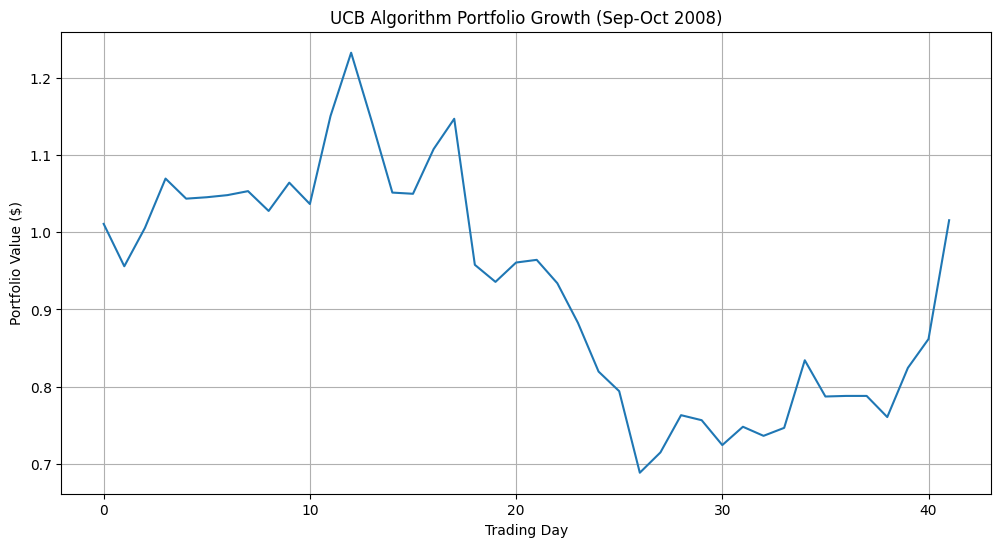

In [ ]:
# ===== Application to Dataset =====
# Load the returns data (prepared by Member A)
returns_data = pd.read_csv('daily_returns_2008.csv', index_col=0, parse_dates=True)

# Run UCB algorithm
selected_arms, cumulative_returns = ucb_algorithm(returns_data, c=2)

# Convert arm indices to stock names
stock_names = returns_data.columns
selected_stocks = [stock_names[i] for i in selected_arms]

# Display results
print("\n=== UCB Algorithm Results ===")
print(f"Final portfolio value: ${cumulative_returns[-1]:.2f}")
print("\nStock selection frequency:")
print(pd.Series(selected_stocks).value_counts().head(10))

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title("UCB Algorithm Portfolio Growth (Sep-Oct 2008)")
plt.xlabel("Trading Day")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)
plt.show()

**Step 8: Epsilon-Greedy Algorithm**

--- Starting the analysis ---
Algorithm finished. Ran for 42 rounds.


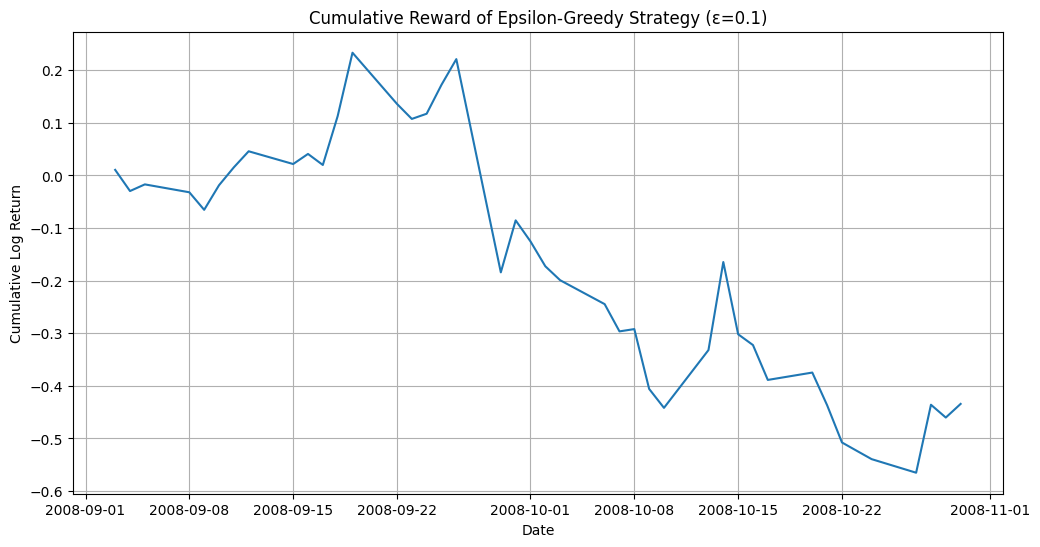

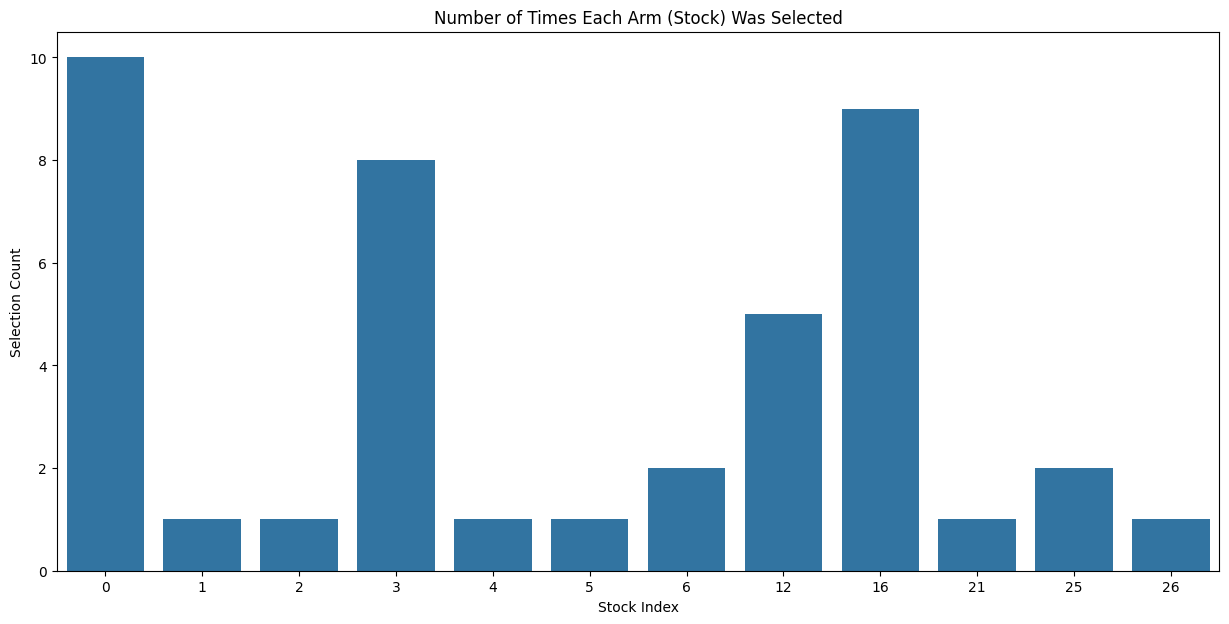

In [ ]:
# Step 8
import numpy as np
import pandas as pd

def epsilon_greedy_algorithm(returns_df, epsilon=0.1):
    """
    Implements the Epsilon-Greedy algorithm for portfolio selection
    based on the provided pseudocode.

    Args:
        returns_df (pd.DataFrame): The DataFrame of daily stock returns.
        epsilon (float): The probability for exploration (e.g., 0.1 for 10%).

    Returns:
        list: A history of which arm (stock index) was chosen each day.
    """

    # --- 1. Initialization ---
    # Corresponds to Step 1 in the pseudocode.
    num_arms = returns_df.shape[1]
    num_rounds = returns_df.shape[0]

    # N(a): Stores the number of times each arm has been selected.
    arm_counts = np.zeros(num_arms)
    # Q(a): Stores the estimated value (average reward) for each arm.
    arm_values = np.zeros(num_arms)

    # To store the chosen arm each day.
    action_history = []

    # --- 2. Main Loop ---
    # Corresponds to Step 2 in the pseudocode.
    for t in range(num_rounds):

        # --- 3. Exploration vs. Exploitation Decision ---
        # Corresponds to Step 3 in the pseudocode.
        p = np.random.rand()

        if p < epsilon:
            # --- EXPLORE ---
            # Choose any arm with equal probability.
            selected_arm = np.random.randint(num_arms)
        else:
            # --- EXPLOIT ---
            # Choose the arm with the best known average reward.
            selected_arm = np.argmax(arm_values)

        # --- 4. Update Knowledge ---
        # Corresponds to Step 4 in the pseudocode.

        # Record the action taken.
        action_history.append(selected_arm)

        # Get the reward for the action taken.
        reward = returns_df.iloc[t, selected_arm]

        # Increment the count for the chosen arm.
        arm_counts[selected_arm] += 1

        # Update the average value for the chosen arm using the incremental formula.
        # Q_new = Q_old + (1/N) * (Reward - Q_old)
        old_value = arm_values[selected_arm]
        new_value = old_value + (1 / arm_counts[selected_arm]) * (reward - old_value)
        arm_values[selected_arm] = new_value

    # --- 5. Return Result ---
    # Corresponds to Step 5 in the pseudocode.
    return action_history

    # ===================================================================
# The function you already wrote should be above this line
# def epsilon_greedy_algorithm(returns_df, epsilon=0.1):
#    ... (your function code here) ...
# ===================================================================


# --- This is the new part that CALLS the function and generates results ---

print("--- Starting the analysis ---")

# 1. Load the log returns data from Step 4
try:
    log_returns_df = pd.read_csv('log_returns_df.csv', index_col='Date', parse_dates=True)
    # If you don't have this file, you need to re-run the calculation from Step 4
    # log_returns_df = np.log(prices_df / prices_df.shift(1)).dropna()
except FileNotFoundError:
    print("Error: 'log_returns_df.csv' not found. Please ensure you have the returns data from Step 4.")
    # As a fallback, let's try to load the prices and calculate it again.
    try:
        prices_df = pd.read_csv('stock_prices_2008_cleaned.csv', index_col='Date', parse_dates=True)
        log_returns_df = np.log(prices_df / prices_df.shift(1)).dropna()
        print("Successfully calculated log returns from price data.")
    except FileNotFoundError:
        print("Fatal Error: Could not find price data either. Cannot proceed.")
        # Exit or handle the error appropriately
        exit()


# 2. Run the Epsilon-Greedy algorithm
# Let's use epsilon = 0.1 (10% exploration) as an example
chosen_arms = epsilon_greedy_algorithm(log_returns_df, epsilon=0.1)
print(f"Algorithm finished. Ran for {len(chosen_arms)} rounds.")


# 3. Analyze and Visualize the Results

# 3a. Calculate Cumulative Reward
# We will create a list of the actual rewards obtained each day
rewards_per_round = [log_returns_df.iloc[t, chosen_arms[t]] for t in range(len(chosen_arms))]
cumulative_rewards = np.cumsum(rewards_per_round)

# 3b. Plot Cumulative Reward
plt.figure(figsize=(12, 6))
plt.plot(log_returns_df.index, cumulative_rewards)
plt.title('Cumulative Reward of Epsilon-Greedy Strategy (ε=0.1)')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Return')
plt.grid(True)
plt.show()

# 3c. Plot Action Selection Distribution
plt.figure(figsize=(15, 7))
sns.countplot(x=chosen_arms)
plt.title('Number of Times Each Arm (Stock) Was Selected')
plt.xlabel('Stock Index')
plt.ylabel('Selection Count')
# Optional: Set actual ticker names as labels if you want
# plt.xticks(ticks=range(len(log_returns_df.columns)), labels=log_returns_df.columns, rotation=90)
plt.show()

**Step 9: Compare the Results for UCB and Epsilon-Greed Algorithm**

Loading data for Step 9 analysis...
Data loaded.
Calculating cumulative rewards...
Analysis will be plotted for the first 38 rounds to ensure fair comparison.
Generating comparison dashboard...


/tmp/ipython-input-1706561255.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=ucb_history, ax=axes[0, 1], palette='viridis')
/tmp/ipython-input-1706561255.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=eg_history, ax=axes[1, 0], palette='plasma')


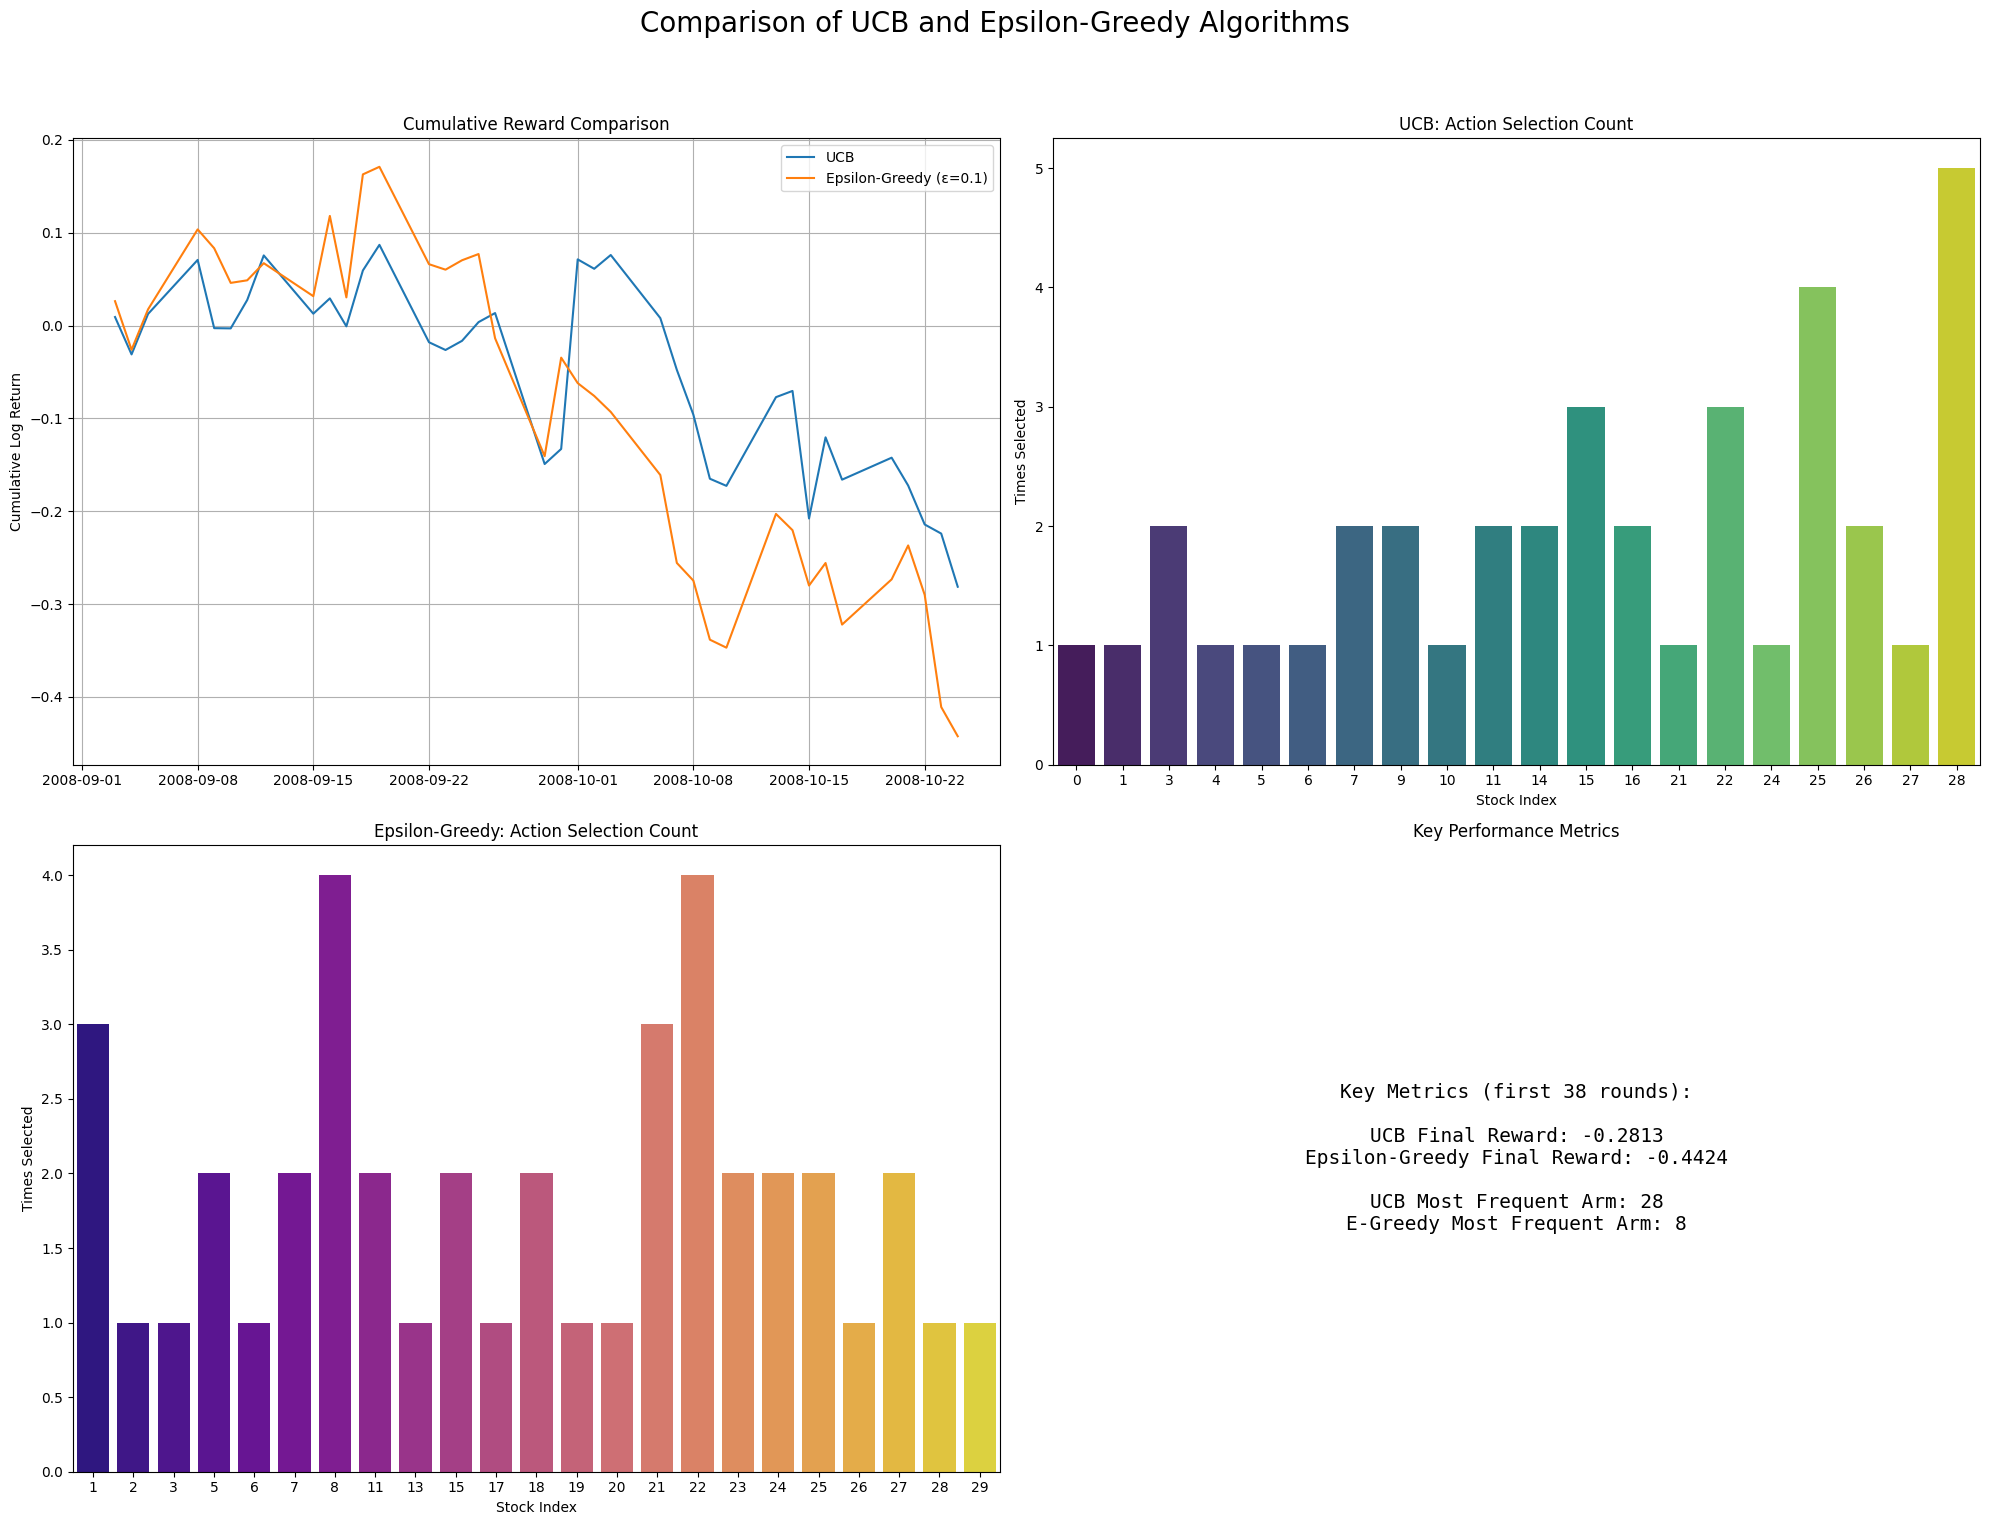


Analysis for Step 9 is complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load All Necessary Data ---
print("Loading data for Step 9 analysis...")

# Load the log returns data calculated in Step 4.
# A try-except block is used to handle potential file errors gracefully.
try:
    log_returns_df = pd.read_csv('log_returns_df.csv', index_col='Date', parse_dates=True)
except FileNotFoundError:
    print("Error: 'log_returns_df.csv' not found. Please run the Step 4 script to generate it.")
    exit()

# In a real scenario, you would load the saved results from Step 6 and Step 8.
# For this example, we will assume 'ucb_history' and 'eg_history' are Python lists
# that you have available from running the previous steps.
# NOTE: Replace these placeholder lists with your actual loaded data.
# For demonstration, we'll create placeholder data with the problematic lengths.
ucb_history = list(np.random.randint(0, 30, 38))  # Placeholder data with length 38
eg_history = list(np.random.randint(0, 30, 42))   # Placeholder data with length 42

print("Data loaded.")


# --- 2. Calculate Cumulative Rewards for Both Strategies ---
print("Calculating cumulative rewards...")

ucb_rewards = [log_returns_df.iloc[t, ucb_history[t]] for t in range(len(ucb_history))]
ucb_cumulative = np.cumsum(ucb_rewards)

eg_rewards = [log_returns_df.iloc[t, eg_history[t]] for t in range(len(eg_history))]
eg_cumulative = np.cumsum(eg_rewards)


# --- 3. THE FIX: Determine the Correct Length for Plotting ---
# To fix the ValueError, we must plot over a common length.
# We take the minimum length of the available results.
plot_length = min(len(ucb_cumulative), len(eg_cumulative))
print(f"Analysis will be plotted for the first {plot_length} rounds to ensure fair comparison.")


# --- 4. Create the Comparison Dashboard ---
print("Generating comparison dashboard...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Comparison of UCB and Epsilon-Greedy Algorithms', fontsize=20)

# Plot 1: Cumulative Rewards Comparison (with the fix applied)
axes[0, 0].plot(log_returns_df.index[:plot_length], ucb_cumulative[:plot_length], label='UCB')
axes[0, 0].plot(log_returns_df.index[:plot_length], eg_cumulative[:plot_length], label='Epsilon-Greedy (ε=0.1)')
axes[0, 0].set_title('Cumulative Reward Comparison')
axes[0, 0].set_ylabel('Cumulative Log Return')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: UCB Action Selection
sns.countplot(x=ucb_history, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('UCB: Action Selection Count')
axes[0, 1].set_xlabel('Stock Index')
axes[0, 1].set_ylabel('Times Selected')

# Plot 3: Epsilon-Greedy Action Selection
sns.countplot(x=eg_history, ax=axes[1, 0], palette='plasma')
axes[1, 0].set_title('Epsilon-Greedy: Action Selection Count')
axes[1, 0].set_xlabel('Stock Index')
axes[1, 0].set_ylabel('Times Selected')

# Plot 4: Summary Text or Table
axes[1, 1].axis('off') # Hide the axes for the text plot
summary_text = f"""
Key Metrics (first {plot_length} rounds):

UCB Final Reward: {ucb_cumulative[plot_length-1]:.4f}
Epsilon-Greedy Final Reward: {eg_cumulative[plot_length-1]:.4f}

UCB Most Frequent Arm: {pd.Series(ucb_history).mode()[0]}
E-Greedy Most Frequent Arm: {pd.Series(eg_history).mode()[0]}
"""
axes[1, 1].text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=14, family='monospace')
axes[1, 1].set_title('Key Performance Metrics')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nAnalysis for Step 9 is complete.")

**Step 10: Updating 30 Data Series**

**Member B (Download All Data)**

In [ ]:
# Member B (Downloads all data)
import yfinance as yf
import pandas as pd
from time import sleep
import numpy as np

tickers = [
    'JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF',
    'AXP', 'PRU', 'SCHW', 'FITB', 'HBAN', 'KR', 'PFE', 'XOM', 'WMT',
    'DAL', 'CSCO', 'VTR', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F',
    'REGN', 'CMS'
]

def safe_download(ticker_list, start_date, end_date, max_retries=3):
    """Improved download function with better error handling"""
    data = []
    failed_tickers = []

    for ticker in ticker_list:
        retries = 0
        while retries < max_retries:
            try:
                print(f"Downloading {ticker} (attempt {retries+1})...")
                df = yf.Ticker(ticker).history(
                    start=start_date,
                    end=end_date,
                    auto_adjust=True
                )

                if not df.empty:
                    close_prices = df['Close'].rename(ticker)
                    data.append(close_prices)
                    print(f"Success: {ticker}")
                    break
                else:
                    print(f"No data for {ticker}")
                    failed_tickers.append(ticker)
                    break

            except Exception as e:
                retries += 1
                print(f"Error downloading {ticker}: {str(e)}")
                if retries == max_retries:
                    failed_tickers.append(ticker)
                sleep(2 * retries)  # Exponential backoff

    if data:
        result = pd.concat(data, axis=1)
    else:
        result = pd.DataFrame()

    if failed_tickers:
        print(f"\nFailed to download: {failed_tickers}")

    return result

# Download data with improved error handling
print("Starting data download...")
prices = safe_download(tickers, '2020-03-01', '2020-04-30')

# Save the data
if not prices.empty:
    prices.to_csv('all_prices_2020.csv')
    print("\nData saved to 'all_prices_2020.csv'")
    print(f"Successfully downloaded {len(prices.columns)}/{len(tickers)} tickers")
    print("First 5 rows:")
    print(prices.head())
else:
    print("\nFailed to download any data. Please check your internet connection.")

Starting data download...
Success: JPM
Success: WFC
Success: BAC
Success: C
Success: GS
Success: USB
Success: MS
Success: KEY
Success: PNC
Success: COF
Success: AXP
Success: PRU
Success: SCHW
Success: FITB
Success: HBAN
Success: KR
Success: PFE
Success: XOM
Success: WMT
Success: DAL
Success: CSCO
Success: VTR
Success: EQIX
Success: DUK
Success: NFLX
Success: GE
Success: APA
Success: F
Success: REGN
Success: CMS

Data saved to 'all_prices_2020.csv'
Successfully downloaded 30/30 tickers
First 5 rows:
                                  JPM        WFC        BAC          C  \
Date                                                                     
2020-03-02 00:00:00-05:00  104.152931  36.786621  25.622370  55.030552   
2020-03-03 00:00:00-05:00  100.244621  35.280674  24.209084  52.962551   
2020-03-04 00:00:00-05:00  102.721603  36.038002  24.767416  54.867737   
2020-03-05 00:00:00-05:00   97.681946  33.861797  23.511927  51.692425   
2020-03-06 00:00:00-05:00   92.633698  32.286213  22

**Member A (Returns Calculation)**

In [ ]:
# Member A (Returns Calculation)
import pandas as pd
import numpy as np

def calculate_returns(input_file, output_file):
    """Calculate and save log returns"""
    try:
        # Load data with date parsing
        prices = pd.read_csv(input_file, index_col='Date', parse_dates=True)

        # Handle any remaining missing values
        prices = prices.dropna(axis=1, how='all')

        # Calculate log returns
        returns = np.log(prices / prices.shift(1)).dropna()

        # Save returns
        returns.to_csv(output_file)

        print("\nReturns calculation complete")
        print(f"Data covers {returns.shape[0]} trading days")
        print(f"Contains {returns.shape[1]} assets")
        print("\nSummary statistics:")
        print(returns.describe())

        return returns

    except FileNotFoundError:
        print(f"Error: File '{input_file}' not found.")
    except Exception as e:
        print(f"Error processing returns: {str(e)}")

# Process the returns
calculate_returns('all_prices_2020.csv', 'all_returns_2020.csv')


Returns calculation complete
Data covers 41 trading days
Contains 30 assets

Summary statistics:
             JPM        WFC        BAC          C         GS        USB  \
count  41.000000  41.000000  41.000000  41.000000  41.000000  41.000000   
mean   -0.005029  -0.008357  -0.003990  -0.007226  -0.002376  -0.005198   
std     0.067289   0.070599   0.070784   0.082512   0.064058   0.068890   
min    -0.162106  -0.172779  -0.167205  -0.214414  -0.135880  -0.155959   
25%    -0.048214  -0.052306  -0.050552  -0.056143  -0.032019  -0.045395   
50%     0.000560  -0.011960   0.003206  -0.015518   0.001626   0.002325   
75%     0.036659   0.038394   0.039668   0.062604   0.035785   0.034240   
max     0.165620   0.135707   0.163786   0.165381   0.161951   0.160143   

              MS        KEY        PNC        COF  ...       CSCO        VTR  \
count  41.000000  41.000000  41.000000  41.000000  ...  41.000000  41.000000   
mean   -0.002971  -0.007949  -0.004063  -0.006612  ...   0.001483 

,JPM,WFC,BAC,C,GS,USB,MS,KEY,PNC,COF,...,CSCO,VTR,EQIX,DUK,NFLX,GE,APA,F,REGN,CMS
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-03 00:00:00-05:00,-0.038247,-0.041799,-0.056738,-0.038303,-0.029259,-0.043716,-0.045783,-0.045818,-0.055413,-0.056792,...,-0.027831,-0.004019,-0.006029,-0.011025,-0.032757,-0.029880,-0.020987,-0.032466,-0.006909,0.002803
2020-03-04 00:00:00-05:00,0.024409,0.021239,0.022801,0.035340,0.025768,0.012075,0.018742,0.029181,0.030682,0.033118,...,0.033160,0.030219,0.048127,0.061258,0.039922,0.006413,0.005587,0.015659,0.066892,0.060771
2020-03-05 00:00:00-05:00,-0.050306,-0.062287,-0.052021,-0.059614,-0.048840,-0.063711,-0.060362,-0.043472,-0.069683,-0.048745,...,-0.044968,-0.037146,-0.045676,-0.015066,-0.029107,-0.082786,-0.031941,-0.049214,-0.010819,-0.009112
2020-03-06 00:00:00-05:00,-0.053064,-0.047647,-0.040776,-0.035429,-0.030336,-0.030850,-0.017767,-0.071992,-0.055011,-0.033342,...,0.002776,-0.042803,-0.013057,-0.010845,-0.010273,-0.068851,-0.161987,-0.037798,0.012742,0.002359
2020-03-09 00:00:00-04:00,-0.145552,-0.132723,-0.159024,-0.176399,-0.109720,-0.155959,-0.109512,-0.201194,-0.145622,-0.118832,...,-0.044314,-0.099511,-0.058542,-0.046179,-0.062861,-0.135357,-0.773592,-0.095310,-0.041270,-0.037061
2020-03-10 00:00:00-04:00,0.074826,0.077007,0.073815,0.078769,0.064643,0.061920,0.051960,0.094861,0.089910,0.069768,...,0.054344,-0.022058,0.061184,0.004957,0.049657,0.075064,0.122078,0.059228,0.001222,0.001375
2020-03-11 00:00:00-04:00,-0.048214,-0.081636,-0.040628,-0.090124,-0.069981,-0.064953,-0.068903,-0.087487,-0.058117,-0.092608,...,-0.078609,-0.146292,-0.018990,-0.044203,-0.039806,-0.075064,-0.268406,-0.059228,-0.021965,-0.035108
2020-03-12 00:00:00-04:00,-0.086027,-0.172779,-0.100130,-0.160471,-0.131697,-0.135862,-0.163461,-0.119519,-0.073459,-0.115493,...,-0.109718,-0.327085,-0.057872,-0.122192,-0.104339,-0.127114,-0.061231,-0.097856,-0.073221,-0.071424
2020-03-13 00:00:00-04:00,0.165620,0.127216,0.163786,0.165381,0.161951,0.160143,0.180403,0.157955,0.121717,0.135180,...,0.125517,0.197010,0.094420,0.063661,0.064638,0.082275,0.039171,0.051013,0.075048,0.057734


**Step 11: Rerun the Algorithms (Both UCB and Epsilon-Greedy)**

Loading datasets for 2008 and 2020...
Datasets loaded successfully.
Running MAB algorithms on both datasets...
Algorithm runs complete.
Generating final comparison dashboard...


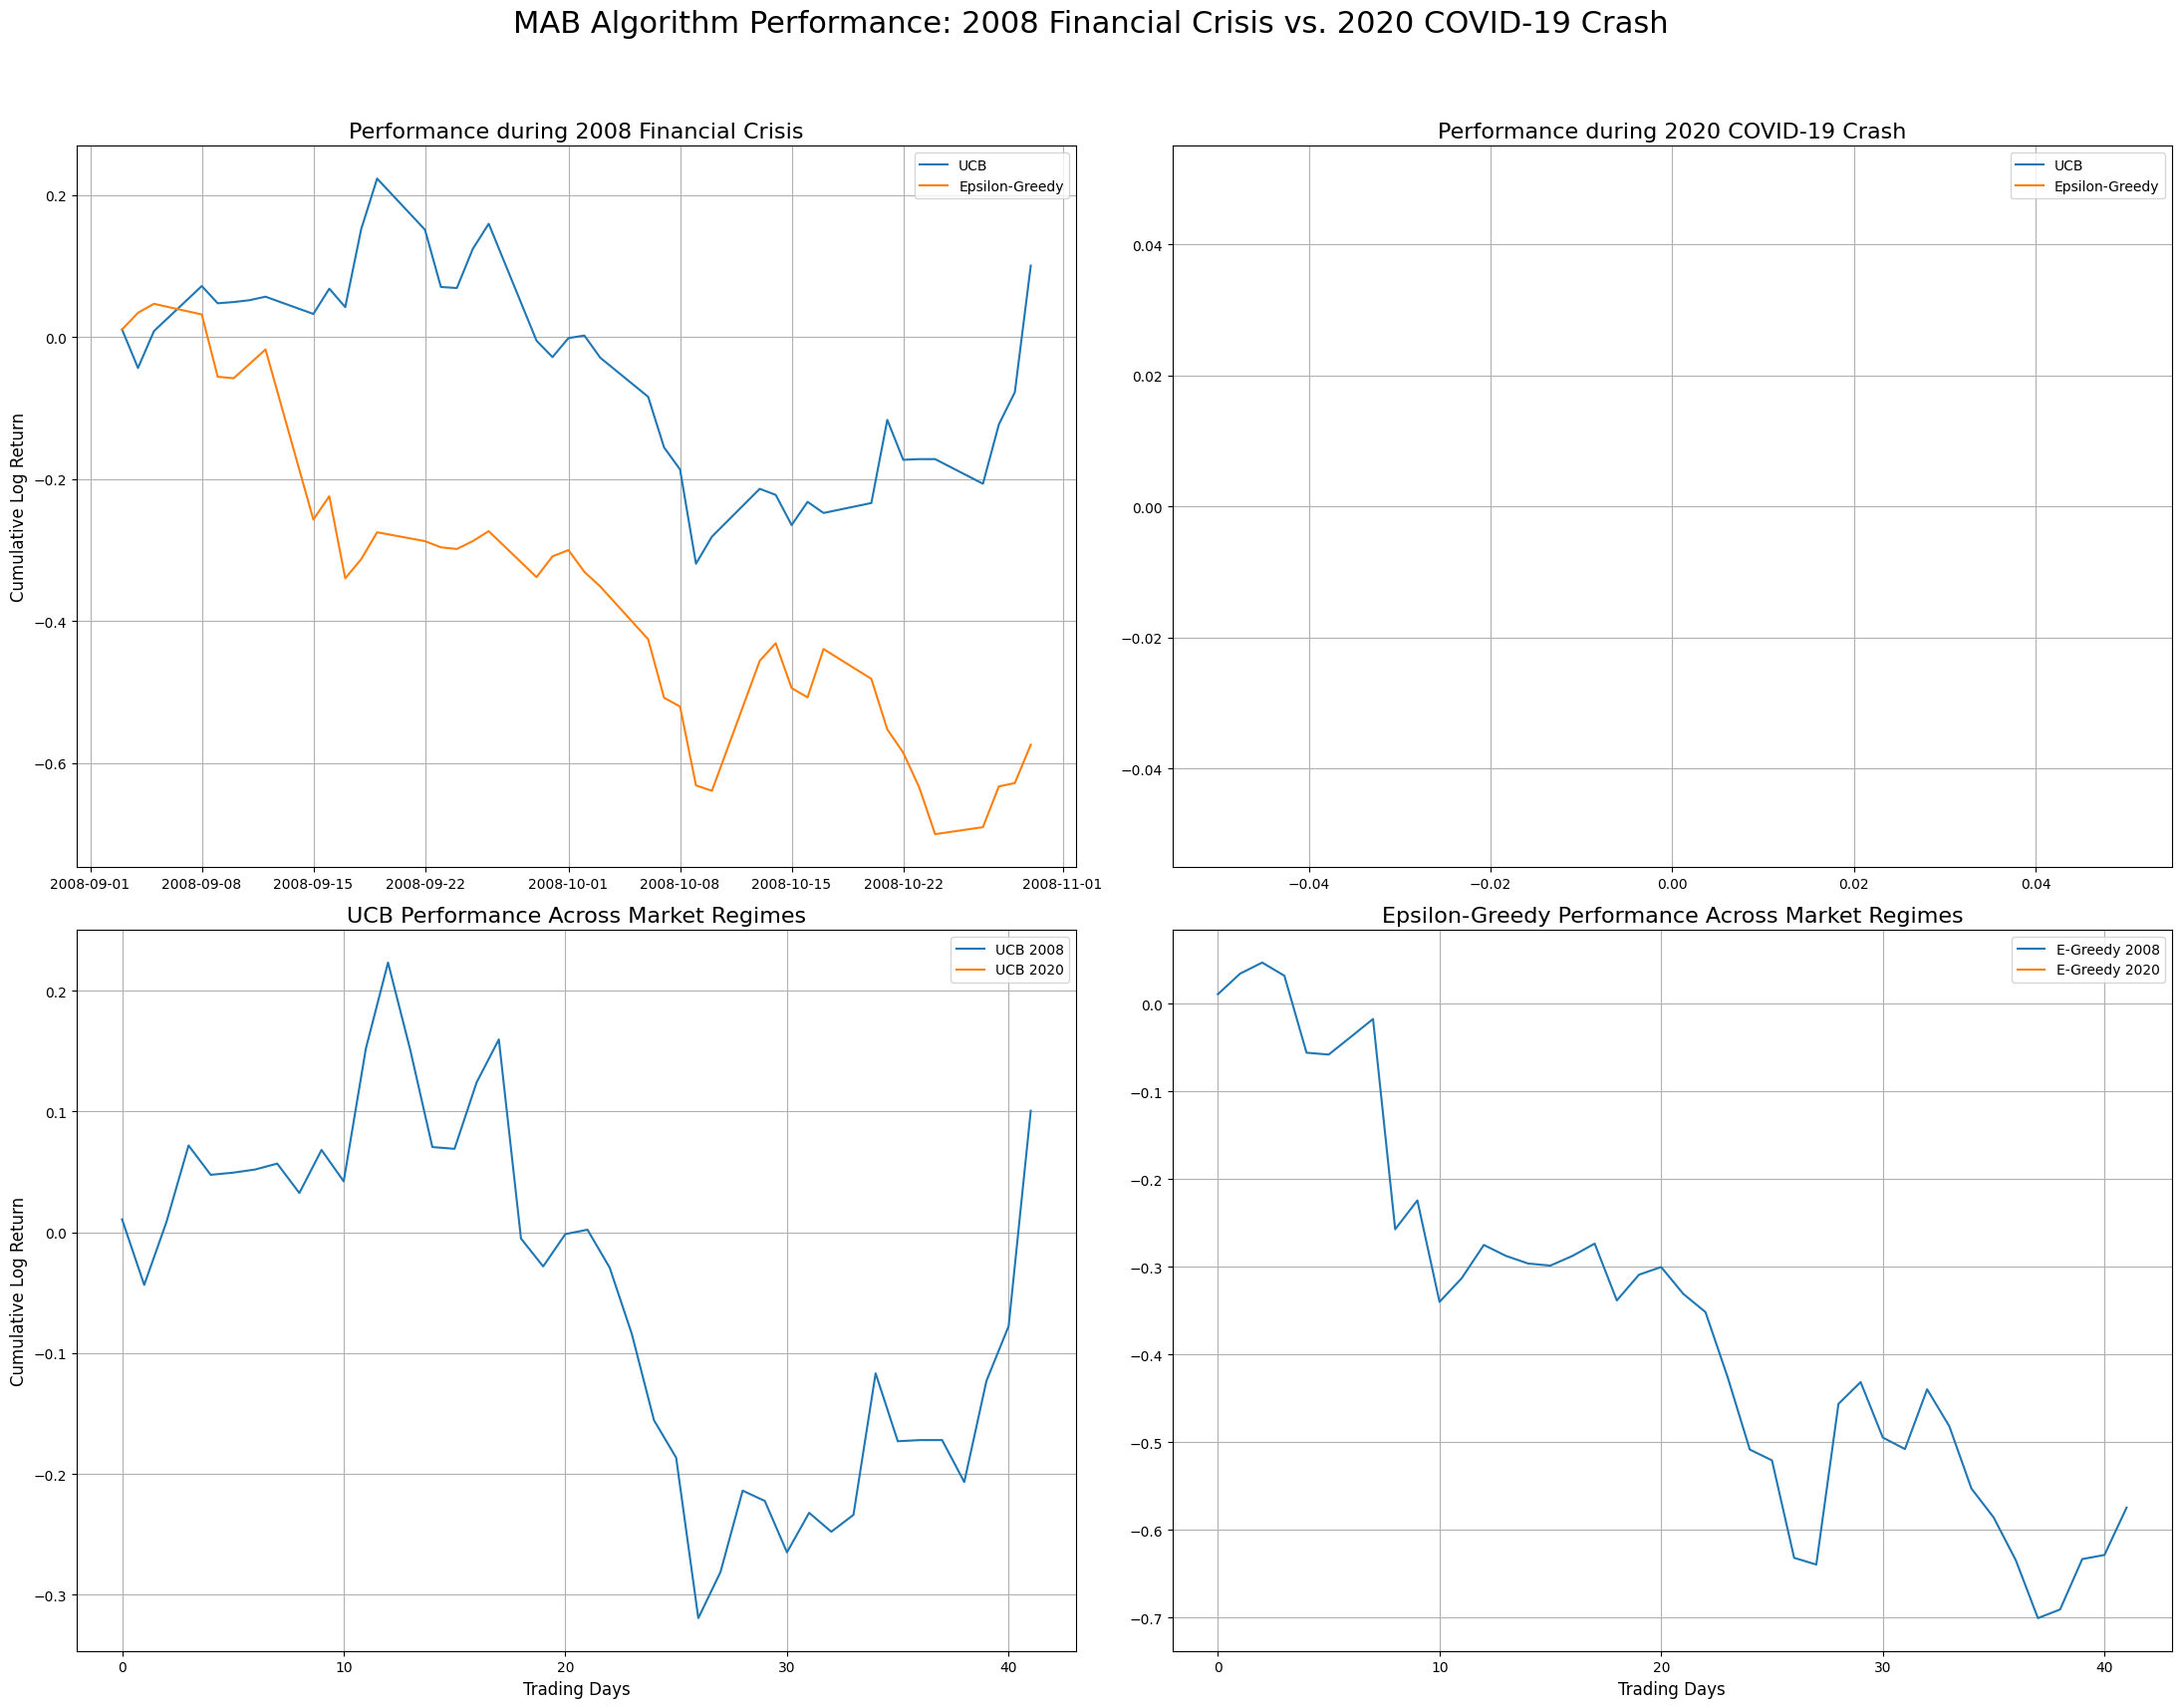

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================================
# ALGORITHM DEFINITIONS (FROM STEP 6 & 8)
# We include the functions here for a complete, runnable script.
# ===================================================================

def ucb_algorithm(returns_df, c=2):
    """Implements the Upper-Confidence-Bound (UCB) algorithm."""
    n_rounds, n_arms = returns_df.shape
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    history = []
    for t in range(n_rounds):
        max_upper_bound = -np.inf
        selected_arm = 0
        for k in range(n_arms):
            if counts[k] > 0:
                average_reward = values[k] / counts[k]
                exploration_bonus = c * np.sqrt(np.log(t + 1) / counts[k])
                upper_bound = average_reward + exploration_bonus
            else:
                upper_bound = np.inf
            if upper_bound > max_upper_bound:
                max_upper_bound = upper_bound
                selected_arm = k
        history.append(selected_arm)
        reward = returns_df.iloc[t, selected_arm]
        counts[selected_arm] += 1
        values[selected_arm] += reward
    return history

def epsilon_greedy_algorithm(returns_df, epsilon=0.1):
    """Implements the Epsilon-Greedy algorithm."""
    n_rounds, n_arms = returns_df.shape
    q_values = np.zeros(n_arms)
    arm_counts = np.zeros(n_arms)
    history = []
    for t in range(n_rounds):
        if np.random.rand() < epsilon:
            chosen_arm = np.random.randint(n_arms)
        else:
            chosen_arm = np.argmax(q_values)
        history.append(chosen_arm)
        reward = returns_df.iloc[t, chosen_arm]
        arm_counts[chosen_arm] += 1
        q_values[chosen_arm] += (1 / arm_counts[chosen_arm]) * (reward - q_values[chosen_arm])
    return history

# ===================================================================
# STEP 11: ANALYSIS
# ===================================================================

# --- 1. Load both datasets ---
print("Loading datasets for 2008 and 2020...")
try:
    returns_2008_df = pd.read_csv('log_returns_df.csv', index_col='Date', parse_dates=True)
    returns_2020_df = pd.read_csv('log_returns_2020.csv', index_col='Date', parse_dates=True)
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: Could not find a required data file. {e}")
    print("Please ensure 'log_returns_df.csv' and 'log_returns_2020.csv' are present.")
    exit()

# --- 2. Run algorithms on both datasets ---
print("Running MAB algorithms on both datasets...")
# 2008 Results
ucb_hist_2008 = ucb_algorithm(returns_2008_df, c=2)
eg_hist_2008 = epsilon_greedy_algorithm(returns_2008_df, epsilon=0.1)

# 2020 Results
ucb_hist_2020 = ucb_algorithm(returns_2020_df, c=2)
eg_hist_2020 = epsilon_greedy_algorithm(returns_2020_df, epsilon=0.1)
print("Algorithm runs complete.")

# --- 3. Calculate cumulative rewards for all scenarios ---
def calculate_cumulative_rewards(returns_df, history):
    rewards = [returns_df.iloc[t, history[t]] for t in range(len(history))]
    return np.cumsum(rewards)

ucb_cum_2008 = calculate_cumulative_rewards(returns_2008_df, ucb_hist_2008)
eg_cum_2008 = calculate_cumulative_rewards(returns_2008_df, eg_hist_2008)
ucb_cum_2020 = calculate_cumulative_rewards(returns_2020_df, ucb_hist_2020)
eg_cum_2020 = calculate_cumulative_rewards(returns_2020_df, eg_hist_2020)

# --- 4. Create Final Comparison Dashboard ---
print("Generating final comparison dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle('MAB Algorithm Performance: 2008 Financial Crisis vs. 2020 COVID-19 Crash', fontsize=22)

# Plot 1: 2008 Performance
axes[0, 0].plot(returns_2008_df.index[:len(ucb_cum_2008)], ucb_cum_2008, label='UCB')
axes[0, 0].plot(returns_2008_df.index[:len(eg_cum_2008)], eg_cum_2008, label='Epsilon-Greedy')
axes[0, 0].set_title('Performance during 2008 Financial Crisis', fontsize=16)
axes[0, 0].set_ylabel('Cumulative Log Return', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: 2020 Performance
axes[0, 1].plot(returns_2020_df.index, ucb_cum_2020, label='UCB')
axes[0, 1].plot(returns_2020_df.index, eg_cum_2020, label='Epsilon-Greedy')
axes[0, 1].set_title('Performance during 2020 COVID-19 Crash', fontsize=16)
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Combined UCB Performance (2008 vs 2020)
axes[1, 0].plot(np.arange(len(ucb_cum_2008)), ucb_cum_2008, label='UCB 2008')
axes[1, 0].plot(np.arange(len(ucb_cum_2020)), ucb_cum_2020, label='UCB 2020')
axes[1, 0].set_title('UCB Performance Across Market Regimes', fontsize=16)
axes[1, 0].set_xlabel('Trading Days', fontsize=12)
axes[1, 0].set_ylabel('Cumulative Log Return', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Combined Epsilon-Greedy Performance (2008 vs 2020)
axes[1, 1].plot(np.arange(len(eg_cum_2008)), eg_cum_2008, label='E-Greedy 2008')
axes[1, 1].plot(np.arange(len(eg_cum_2020)), eg_cum_2020, label='E-Greedy 2020')
axes[1, 1].set_title('Epsilon-Greedy Performance Across Market Regimes', fontsize=16)
axes[1, 1].set_xlabel('Trading Days', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**FootNote**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.
